## Run DOLPHOT on simulated Rosesim images and do artificial star injection tests

In [286]:
# Import packages
%load_ext autoreload
%autoreload 2

import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import os
from astropy.io import fits
from kuaizi.display import display_single

import romanisim
import romanisim.parameters
import romanisim.bandpass
from astropy.table import Table, hstack, vstack
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

import sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')
from display import show_image_wcs

from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [287]:
import ripples

## 1. Check DOLPHOT residuals

In [285]:
exptime = 600
host = 'sky_jaguar_trilegal_n253'
# host = 'cena'

In [288]:
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
!pwd

/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/sky_jaguar_trilegal_n253


(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f8e3d4eb150>})

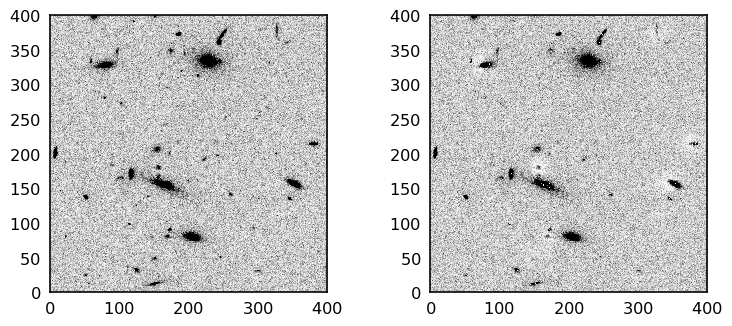

In [289]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

hdu = fits.open(f'./F106_600s_LINEGAP5_1.0.fits')
_, _, norm = show_image_wcs(hdu[0].data[300:700,300:700], fig=fig, ax=ax1, percl=99)
w = WCS(hdu[0].header)

# The residual image after DOLPHOT. You'll see lots of point sources disappear.
# hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.1.res.fits')
hdu = fits.open(f'./{host}_3000s.phot.1.res.fits')
show_image_wcs(hdu[0].data[300:700,300:700], fig=fig, ax=ax2, scale_args=norm)

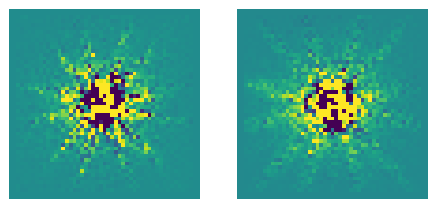

In [290]:
# This shows the "correction" term to the fiducial Roman PSF templates, as we downloaded when installing DOLPHOT
exptime = 3000
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 3))
hdu = fits.open(f'./{host}_{exptime}s_fitsky1/{host}_{exptime}s.phot.1.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax1);
hdu = fits.open(f'./{host}_{exptime}s_fitsky1/{host}_{exptime}s.phot.10.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax2);

## 2. Check the DOLPHOT catalog

In [291]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas
from rosesim import Roman_zp_AB_Vega_parsec

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    # flag &= (cat['qflag_f158'] <= 4)
    # flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2) # (1=bright star, 2=faint, 3=elongated, 4=hot pixel, 5=extended)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

In [292]:
# plt.scatter(cat['mag_ab_f106'], cat['mag_ab_f106'] - cat['mag_vega_f106'])
# plt.ylim(-2, 2)

In [301]:
exptime = 3000
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s_fitsky1/{host}_{exptime}s.phot', 
                       f'./{host}_{exptime}s_fitsky1/{host}_{exptime}s.phot.columns', fake=False)

Filters: ['F106', 'F158']


Text(0, 0.5, 'sharp')

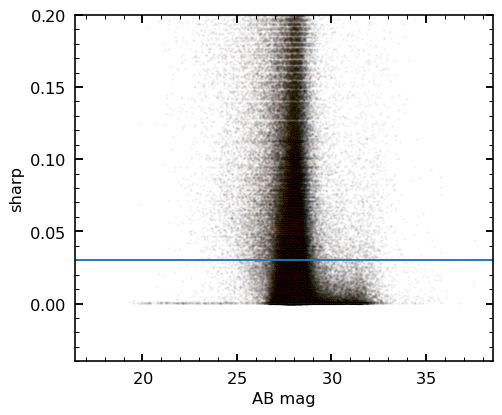

In [303]:
cat['ra'], cat['dec'] = w.all_pix2world(cat['x'], cat['y'], 1)

plt.scatter(cat['mag_ab_f106'], abs(cat['sharp_f106'])**2, s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], abs(cat['sharp_f158'])**2, s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('sharp')

In [304]:
# plt.scatter(cat['crowd_f106'], cat['crowd_f106'] - cat['crowd_f158'], s=3)
# plt.ylim(-1, 1)

Text(0, 0.5, 'crowd')

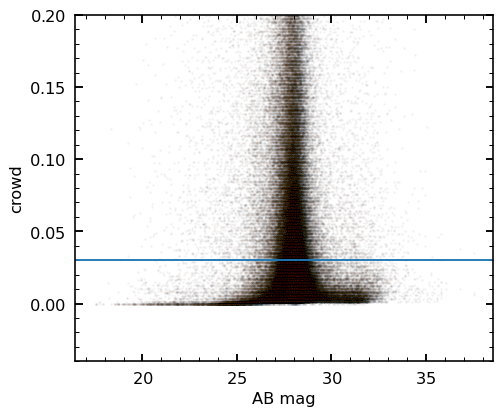

In [305]:
plt.scatter(cat['mag_ab_f106'], (cat['crowd_f106']), s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], (cat['crowd_f158']), s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)

plt.xlabel('AB mag')
plt.ylabel('crowd')

Text(0, 0.5, '$m_{\\rm combined} - m_{\\rm i}$')

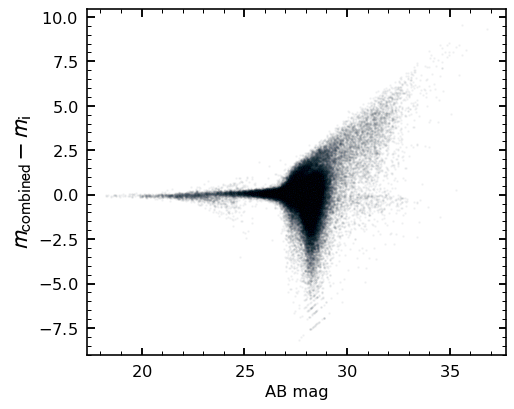

In [306]:
plt.scatter(cat['mag_ab_f106'], cat['mag_ab_f106'] - cat['mag_ab_f106_linegap5_1_0'], s=1, alpha=0.04)
plt.xlabel('AB mag')
plt.ylabel(r'$m_{\rm combined} - m_{\rm i}$', fontsize=20)
# plt.ylim(-0.6, 0.6)

In [307]:
crowd_cut = 0.5
sharp_cut = 0.03
cat['good_flag'] = quality_cut(cat, snr=3, 
                               crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                               sharp={'f158': sharp_cut, 'f106': sharp_cut})
cat['star_flag'] = point_source_cut(cat, snr=3, 
                                    crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                                    sharp={'f158': sharp_cut, 'f106': sharp_cut})

In [308]:
np.sum(cat['star_flag']), np.sum(cat['good_flag'])

(np.int64(19530), np.int64(68477))

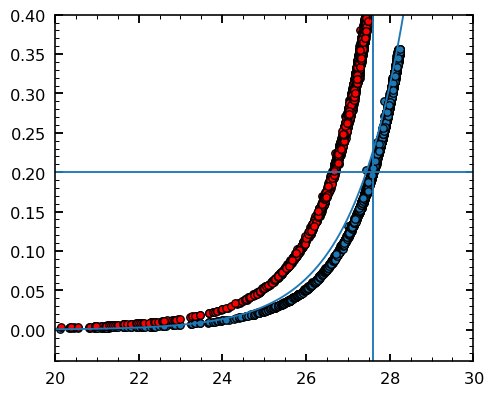

In [309]:
# plt.scatter(cat['mag_ab_f158_sub4_dither0'], cat['mag_err_f158_sub4_dither0'])
flag = cat['star_flag']
plt.scatter(cat['mag_ab_f158'][flag], cat['mag_err_f158'][flag])
# plt.scatter(cat['mag_ab_f158'], cat['mag_err_f158'], c=cat['obj_type'])
# plt.colorbar()

plt.scatter(cat['mag_ab_f158_linegap5_1_0'][flag], cat['mag_err_f158_linegap5_1_0'][flag], c='r')

mag = np.linspace(20, 29, 100)
plt.plot(mag, mag_uncertainty_func(mag, 0.33950503, -10.01496388))

plt.ylim(-0.04, 0.4)
plt.xlim(20, 30)
plt.axvline(27.6)
plt.axhline(1/5)

Text(0, 0.5, 'F158 [AB mag]')

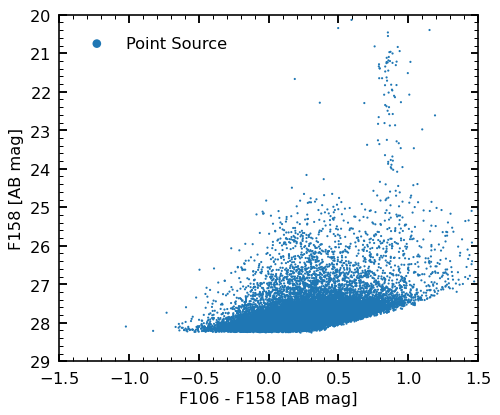

In [310]:
# plt.scatter(cat['mag_ab_f106'] - cat['mag_ab_f158'], cat['mag_ab_f158'],
#             ec='none', s=3, label='Dolphot all')

# flag = (cat['good_flag']) & (~cat['star_flag'])
# plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
#             ec='none', s=3, label='Dolphot Good')

flag = cat['star_flag']
plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
            ec='none', s=3, label='Point Source')

# plt.scatter(cat[flag]['mag_ab_f106_sub4_dither0'] - cat[flag]['mag_ab_f158_sub4_dither0'], cat[flag]['mag_ab_f158_sub4_dither0'], 
#             ec='none', s=3, label='Dolphot Single')

# plt.scatter(-2.5 * np.log10(truth_cat['F106'] / truth_cat['F158']), -2.5 * np.log10(truth_cat['F158']), 
#             fc='none', s=60, alpha=0.1)

# plt.scatter(ufd['MAG_F106'] - ufd['MAG_F158'], ufd['MAG_F158'], ec='none', s=3)

# dmod = 5 * np.log10(4) + 25
# flag = iso.eep <= 7

# filt1, filt2 = "F106", "F158"

# plt.plot((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          c='darkviolet', lw=3, label='Isochrone')

# flag = iso.eep >= 7
# plt.scatter((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          fc='darkviolet', ec='none', s=1)


plt.xlim(-1.5, 1.5)
plt.ylim(29, 20)
plt.xlim()
plt.legend(markerscale=4.0)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

## Spatial match

In [198]:
temp = cat[cat['star_flag']]
temp_truth = truth_cat[~np.isnan(truth_cat['ra'])]
# temp_truth = temp_truth[(-2.5 * np.log10(temp_truth['F158']) < 27)]
out = xmatch_true_meas(temp_truth, temp, radius=0.4 * u.arcsec)

Text(0, 0.5, 'Completeness')

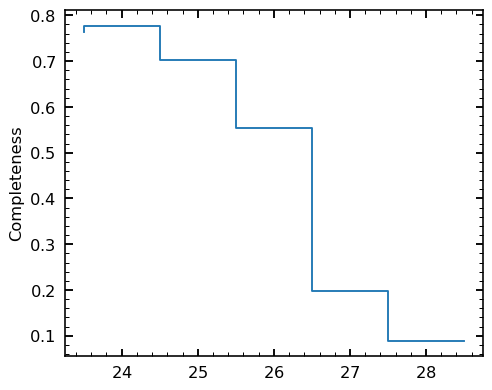

In [200]:
out = xmatch_true_meas(temp, temp_truth, radius=0.4 * u.arcsec)

flag = (out['has_match'])
n_obs, bin_edges = np.histogram(-2.5 * np.log10(out[flag]['meas_F158']), bins=np.linspace(23, 29, 7))
n_true, bin_edges = np.histogram(-2.5 * np.log10(out['meas_F158']), bins=np.linspace(23, 29, 7))
cen = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.step(cen, n_obs / n_true)
plt.ylabel('Completeness')

Text(0, 0.5, 'Dec [deg]')

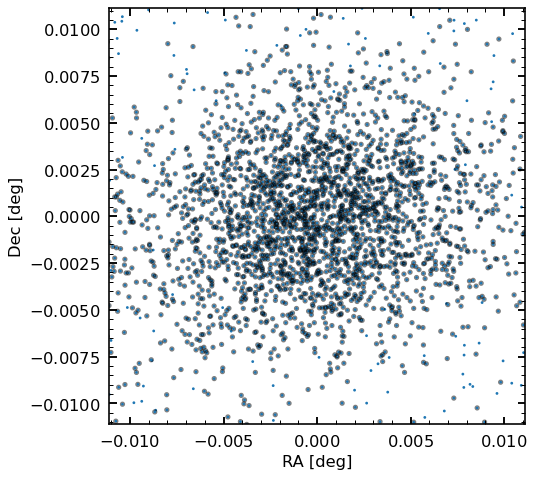

In [203]:
obs_ra, obs_dec = 150, 0

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(temp['ra'] - obs_ra, temp['dec'] - obs_dec, s=5, ec='none')

flag = (out['has_match'])
plt.scatter(out[flag]['true_ra'] - obs_ra, out[flag]['true_dec'] - obs_dec, s=10, fc='none', alpha=0.5)

# plt.scatter(out[flag]['meas_ra'] - obs_ra, out[flag]['meas_dec'] - obs_dec, s=100, fc='none', alpha=0.5)
# flag = (-2.5 * np.log10(truth_cat['F158']) < 27)
# plt.scatter(truth_cat[flag]['ra'] - obs_ra, truth_cat[flag]['dec'] - obs_dec, s=10, fc='none', alpha=0.5)

extent = 40
plt.xlim(-extent/3600, extent/3600)
plt.ylim(-extent/3600, extent/3600)
plt.gca().set_aspect('equal')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

### Check star-galaxy separation very naiively

In [311]:
cat_ps = cat[cat['star_flag']]

In [312]:
true_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_ngc253/temp/sky_table_sky_jaguar_trilegal_ngc253.LINEGAP5_1.0.ecsv')
# true_cat = Table.read(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal_cena/temp/sky_table_sky_jaguar_trilegal_cena_sizecut_642s.ecsv')
# true_cat = true_cat[true_cat['type'] == 'PSF']
out = xmatch_true_meas(true_cat, cat_ps, radius=0.4 * u.arcsec)

In [313]:
len(true_cat), len(out), len(cat_ps)

(64506, 19530, 19530)

(0.0, 1.1)

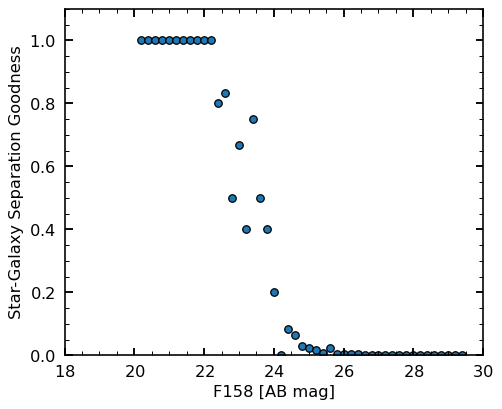

In [314]:
comp_bins = np.arange(17.5, 29.6, 0.2)
res = binned_statistic(-2.5 * np.log10(out['true_F158']), 
                       out['true_type'] == 'PSF', 
                       bins=comp_bins, 
                       statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp)

plt.ylabel('Star-Galaxy Separation Goodness')
plt.xlabel('F158 [AB mag]')

plt.xlim(18, 30)
plt.ylim(0, 1.1)

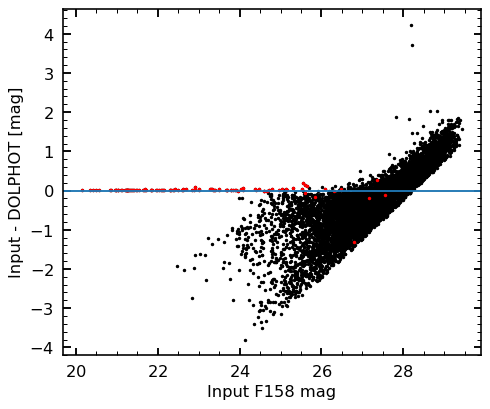

In [315]:
plt.scatter(-2.5 * np.log10(out['true_F158']), -2.5 * np.log10(out['true_F158']) - out['meas_mag_ab_f158'], s=3, color='k')

flag = out['true_type'] == 'PSF'
plt.scatter(-2.5 * np.log10(out[flag]['true_F158']), 
            -2.5 * np.log10(out[flag]['true_F158']) - out[flag]['meas_mag_ab_f158'], s=3, color='r')

# plt.ylim(-0.4, 0.4)

plt.xlabel('Input F158 mag')
plt.ylabel('Input - DOLPHOT [mag]')
plt.axhline(0)

## 3. Artificial Star Tests to derive completeness and photometric uncertainties

We use a function `quality_cut` to cull the catalog. If the `good_flag` is true, it passes the QA criteria in the `quality_cut` function. See here for more information on QA cuts: https://dolphot-jwst.readthedocs.io/en/latest/post-processing/catalogs.html

We also assume that the oc

In [96]:
from rosesim.utils import read_dolphot_cat, delta_m_scatter_vs_mag, logistic_completeness, mag_uncertainty_func, fit_logistic_completeness

In [253]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas
from rosesim import Roman_zp_AB_Vega_parsec

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2) # (1=bright star, 2=faint, 3=elongated, 4=hot pixel, 5=extended)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    # flag &= (cat['chi_f106'] < 3)
    # flag &= (cat['chi_f158'] < 3) # this is tbd
    return flag

In [271]:
# Here we load the AST output catalog,
exptime = 3000
# fake = read_dolphot_cat(f'./{host}_{exptime}s/fake_n253_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)
fake = read_dolphot_cat(f'./fake_n253_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)

crowd_cut = 0.5
sharp_cut = 0.03

# We apply QA cuts
fake['star_flag'] = point_source_cut(fake, snr=3, 
                                     crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                                     sharp={'f158': sharp_cut, 'f106': sharp_cut})
fake['good_flag'] = quality_cut(fake, snr=3, 
                               crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                               sharp={'f158': sharp_cut, 'f106': sharp_cut})
len(fake)

Filters: ['F106', 'F158']
tag_filter_combos [('LINEGAP5_1.0', 'F106'), ('LINEGAP5_1.1', 'F106'), ('LINEGAP5_1.2', 'F106'), ('LINEGAP5_1.3', 'F106'), ('LINEGAP5_1.4', 'F106'), ('LINEGAP5_1.0', 'F158'), ('LINEGAP5_1.1', 'F158'), ('LINEGAP5_1.2', 'F158'), ('LINEGAP5_1.3', 'F158'), ('LINEGAP5_1.4', 'F158')]
Converting counts_true_f106_linegap5_1_0 to mag_true_f106_linegap5_1_0
Converting counts_true_f106_linegap5_1_1 to mag_true_f106_linegap5_1_1
Converting counts_true_f106_linegap5_1_2 to mag_true_f106_linegap5_1_2
Converting counts_true_f106_linegap5_1_3 to mag_true_f106_linegap5_1_3
Converting counts_true_f106_linegap5_1_4 to mag_true_f106_linegap5_1_4
Converting counts_true_f158_linegap5_1_0 to mag_true_f158_linegap5_1_0
Converting counts_true_f158_linegap5_1_1 to mag_true_f158_linegap5_1_1
Converting counts_true_f158_linegap5_1_2 to mag_true_f158_linegap5_1_2
Converting counts_true_f158_linegap5_1_3 to mag_true_f158_linegap5_1_3
Converting counts_true_f158_linegap5_1_4 to mag_true_f15

3267

In [272]:
# input mags are in Vega

### 3.1 Completeness

In [273]:
# fake['good_flag'] = quality_cut(fake, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}) 

Best fit completeness for f106: 27.587336230425297 0.4872252849153964
Best fit completeness for f158: 27.205089121804185 0.5526688377398378


Text(0.5, 1.0, 'High Galactic Latitude Field (NGC 253)')

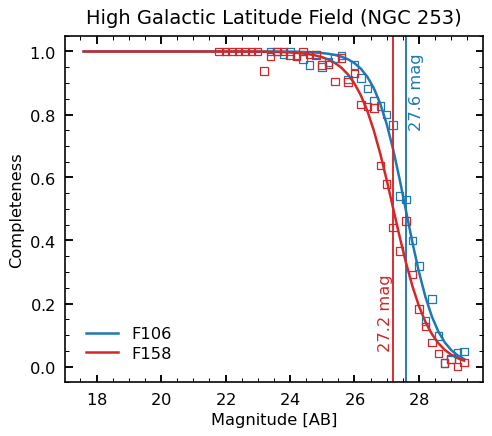

In [274]:
comp_bins = np.arange(17.5, 29.6, 0.2)
mag_50_dict = {}
colors = {'f106': 'C0', 'f158': 'C3'}
tag = 'linegap5_1_0'

filt = 'f106'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt]+0.1, 0.75, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='left', va='bottom')


filt = 'f158'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt], 0.05, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='right', va='bottom')

plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.title('High Galactic Latitude Field (NGC 253)')

### 3.2 Photometric uncertainty

Best fit in f106 : [  0.33950503 -10.01496388]
Best fit in f158 : [  0.34653349 -10.10208302]

Photometric uncertainty dict:
{'f106': array([  0.33950503, -10.01496388]), 'f158': array([  0.34653349, -10.10208302])}


(20.0, 29.0)

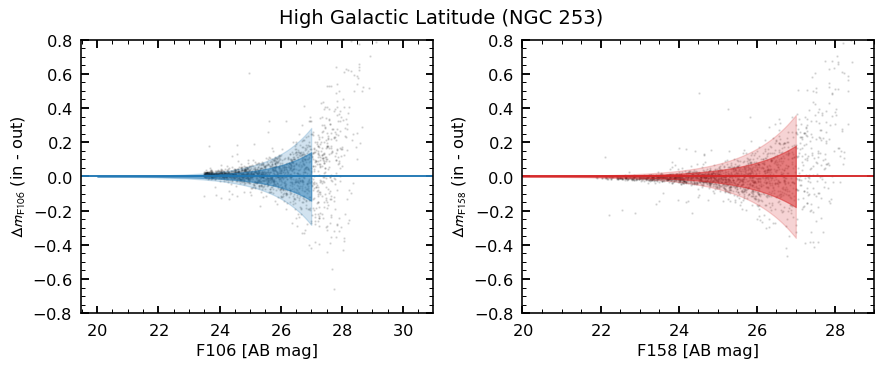

In [277]:
bands = ['f106', 'f158']
fig, axes = plt.subplots(1, len(bands), figsize=(10, 4))
tag = 'linegap5_1_0'

coeffs_dict = {}

fake_good = fake[fake['star_flag']]

for i, filt in enumerate(bands):
    # Fit for a relation between mag and mag_err
    delta_m = fake_good[f'mag_true_{filt}_{tag}'] - fake_good[f'mag_ab_{filt}']
    mag_bins = np.arange(23.0, 27, 0.3)
    scatter_tab = delta_m_scatter_vs_mag(
        fake_good[f'mag_true_{filt}_{tag}'], delta_m,
        mag_bins=mag_bins, clip_sigma=3.0,
        clip_iters=3, method="mad", min_per_bin=20,
    )
    flag = (scatter_tab['mag_center'] <= 27) & ~np.isnan(scatter_tab['scatter'])
    coeffs_dict[filt] = np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1)
    print(f'Best fit in {filt} :', coeffs_dict[filt])

    plt.sca(axes[i])
    plt.scatter(fake_good[f'mag_true_{filt}_{tag}'], delta_m,  s=1, c='k', alpha=0.1)
    _x = np.linspace(20, 27, 100)
    sigma_pred = 10**(coeffs_dict[filt][0] * _x + coeffs_dict[filt][1])
    plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color=colors[filt])
    plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color=colors[filt])
    plt.axhline(0, color=colors[filt])
    plt.ylim(-0.8, 0.8)
    # plt.ylim(-0.1, 0.1)
    plt.xlabel(f'{filt.upper()} [AB mag]')
    plt.ylabel(r'$\Delta m_{\rm ' + filt.upper() + '}$ (in - out)')

plt.tight_layout()
plt.suptitle('High Galactic Latitude (NGC 253)', y=1.02)
print('\nPhotometric uncertainty dict:')
print(coeffs_dict)

plt.xlim(20, 29)


## Compile the whole thing

Text(0.5, 1.07, 'NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)')

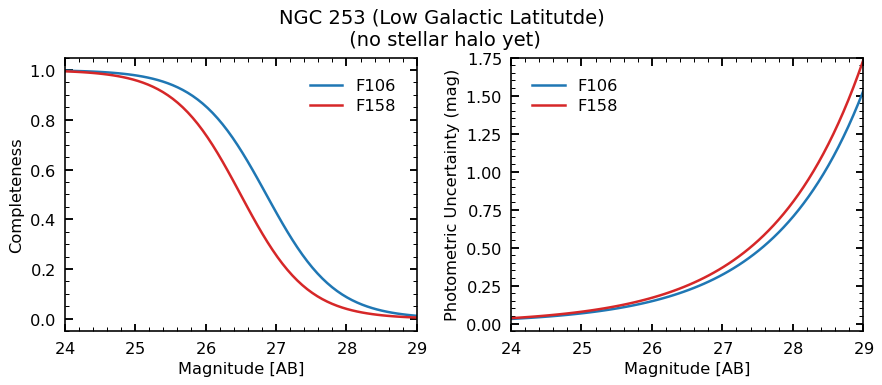

In [59]:
completeness_dict = {'F106': [26.861374163343974, 0.4849778783627637], 
                     'F158': [26.497107133874497, 0.47279379137194777]} # HLWAS depth
mag_uncertainty_dict = {'F106': [0.33849183, -9.63146925], 
                        'F158': [0.33611677, -9.50851665]} # HLWAS depth, DOLPHOT

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

plt.sca(ax1)
mag = np.linspace(22, 29, 100)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F106']), label='F106', color=colors['f106'], lw=2)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F158']), label='F158', color=colors['f158'], lw=2)
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.ylim(-0.05, 1.05)

plt.sca(ax2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F106']), label='F106', c=colors['f106'], lw=2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F158']), label='F158', c=colors['f158'], lw=2)
# plt.axvline(26.5, color='C0', label='F106 limit', ls=':')
# plt.axvline(26.4, color='C1', label='F158 limit', ls=':')
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Photometric Uncertainty (mag)')
plt.ylim(-0.05, 1.75)

plt.tight_layout()
plt.suptitle('NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)', y=1.07)